<center>
<img src="https://laelgelcpublic.s3.sa-east-1.amazonaws.com/lael_50_years_narrow_white.png.no_years.400px_96dpi.png" width="300" alt="LAEL 50 years logo">
<h3>APPLIED LINGUISTICS GRADUATE PROGRAMME (LAEL)</h3>
</center>
<hr>

# Corpus Linguistics - Study 1 - Phase 4 - Andrea

This document aims to organise the commercial verbal and visual subcorpora data for Canonical Correlation Analysis (CCA).

## Commercial Verbal Subcorpus

Define the project name.

In [1]:
PROJECT = "cl_st1_ph2_andrea"

In [2]:
from pathlib import Path

SCORES_FILE = Path(f"../{PROJECT}/sas/output_{PROJECT}/{PROJECT}_scores_only.tsv")
FILE_IDS_PATH = Path(f"../{PROJECT}/file_ids.txt")

### Load factor scores

In [3]:
import pandas as pd

scores_verbal_df = pd.read_csv(SCORES_FILE, sep="\t")
scores_verbal_df = scores_verbal_df.rename(columns={"filename": "file_id"})

scores_verbal_df

,file_id,decade,group,fac1,fac2,fac3,fac4,fac5,fac6,fac7,...,v000258,v000259,v000260,v000261,v000262,v000263,v000264,v000265,v000266,v000267
0,t000001,1950,1950,1,-1,0,-3,1,0,2,...,0,0,0,0,0,0,0,0,0,0
1,t000002,1950,1950,8,0,3,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,t000003,1950,1950,4,1,-1,-8,0,-1,2,...,0,0,0,1,0,0,0,0,0,0
3,t000004,1950,1950,2,1,-1,-1,-6,1,-1,...,0,0,0,0,0,0,1,0,0,0
4,t000005,1950,1950,3,0,1,0,0,-1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
815,t000820,2020,2020,2,1,1,-1,-1,0,0,...,0,0,0,0,0,0,0,0,0,0
816,t000821,2020,2020,-1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
817,t000822,2020,2020,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
818,t000823,2020,2020,2,0,1,1,0,-2,0,...,0,0,0,0,0,0,0,0,0,1


### Load file ID mapping

In [4]:
file_ids_verbal_df = pd.read_csv(
    FILE_IDS_PATH,
    sep=" ",
    names=["file_id", "group_filename"],
)

file_ids_verbal_df.head()

,file_id,group_filename
0,t000001,1950/tv_com_1950_1.txt
1,t000002,1950/tv_com_1950_3.txt
2,t000003,1950/tv_com_1950_5.txt
3,t000004,1950/tv_com_1950_6.txt
4,t000005,1950/tv_com_1950_7.txt


### Merge factor scores with file ID mapping

In [5]:
scores_file_ids_verbal_df = scores_verbal_df.merge(file_ids_verbal_df, on="file_id", how="left")
scores_file_ids_verbal_df = scores_file_ids_verbal_df[
    ["file_id", "group_filename"]
    + [col for col in scores_file_ids_verbal_df.columns if col not in ["file_id", "group_filename"]]
    ]

scores_file_ids_verbal_df

,file_id,group_filename,decade,group,fac1,fac2,fac3,fac4,fac5,fac6,...,v000258,v000259,v000260,v000261,v000262,v000263,v000264,v000265,v000266,v000267
0,t000001,1950/tv_com_1950_1.txt,1950,1950,1,-1,0,-3,1,0,...,0,0,0,0,0,0,0,0,0,0
1,t000002,1950/tv_com_1950_3.txt,1950,1950,8,0,3,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,t000003,1950/tv_com_1950_5.txt,1950,1950,4,1,-1,-8,0,-1,...,0,0,0,1,0,0,0,0,0,0
3,t000004,1950/tv_com_1950_6.txt,1950,1950,2,1,-1,-1,-6,1,...,0,0,0,0,0,0,1,0,0,0
4,t000005,1950/tv_com_1950_7.txt,1950,1950,3,0,1,0,0,-1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
815,t000820,2020/tv_com_2020_114.txt,2020,2020,2,1,1,-1,-1,0,...,0,0,0,0,0,0,0,0,0,0
816,t000821,2020/tv_com_2020_115.txt,2020,2020,-1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
817,t000822,2020/tv_com_2020_116.txt,2020,2020,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
818,t000823,2020/tv_com_2020_118.txt,2020,2020,2,0,1,1,0,-2,...,0,0,0,0,0,0,0,0,0,1


### Prepare verbal factor-score columns for CCA

Rename the verbal factor-score columns from `fac<n>` to `ver<n>` and keep only the file identifiers, decade metadata, and renamed verbal score columns needed for Canonical Correlation Analysis.

In [6]:
import re

verbal_factor_cols = [col for col in scores_file_ids_verbal_df.columns if re.fullmatch(r"fac\d+", col)]
verbal_factor_cols = sorted(verbal_factor_cols, key=lambda col: int(col.replace("fac", "")))

verbal_rename_map = {
    col: col.replace("fac", "ver")
    for col in verbal_factor_cols
}

scores_file_ids_verbal_df = scores_file_ids_verbal_df.rename(columns=verbal_rename_map)

verbal_cols = [verbal_rename_map[col] for col in verbal_factor_cols]

scores_file_ids_verbal_df = scores_file_ids_verbal_df[
    ["file_id", "group_filename", "decade"] + verbal_cols
    ]

scores_file_ids_verbal_df

,file_id,group_filename,decade,ver1,ver2,ver3,ver4,ver5,ver6,ver7,ver8
0,t000001,1950/tv_com_1950_1.txt,1950,1,-1,0,-3,1,0,2,2
1,t000002,1950/tv_com_1950_3.txt,1950,8,0,3,1,1,1,0,2
2,t000003,1950/tv_com_1950_5.txt,1950,4,1,-1,-8,0,-1,2,0
3,t000004,1950/tv_com_1950_6.txt,1950,2,1,-1,-1,-6,1,-1,1
4,t000005,1950/tv_com_1950_7.txt,1950,3,0,1,0,0,-1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
815,t000820,2020/tv_com_2020_114.txt,2020,2,1,1,-1,-1,0,0,-1
816,t000821,2020/tv_com_2020_115.txt,2020,-1,0,0,0,0,0,0,0
817,t000822,2020/tv_com_2020_116.txt,2020,0,0,0,0,0,0,0,0
818,t000823,2020/tv_com_2020_118.txt,2020,2,0,1,1,0,-2,0,2


## Commercial Visual Subcorpus

Define the project name.

In [7]:
PROJECT = "cl_st1_ph3_andrea"

In [8]:
from pathlib import Path

SCORES_FILE = Path(f"../{PROJECT}/sas/output_{PROJECT}/{PROJECT}_scores_only.tsv")
FILE_IDS_PATH = Path(f"../{PROJECT}/file_ids.txt")

### Load factor scores

In [9]:
import pandas as pd

scores_visual_df = pd.read_csv(SCORES_FILE, sep="\t")
scores_visual_df = scores_visual_df.rename(columns={"filename": "file_id"})

scores_visual_df

,file_id,decade,group,fac1,fac2,fac3,fac4,fac5,fac6,fac7,...,v000964,v000965,v000966,v000967,v000968,v000969,v000970,v000971,v000972,v000973
0,t000001,1950,1950,7,0,6,3,1,3,9,...,0,0,0,0,0,0,0,0,0,0
1,t000002,1950,1950,3,5,13,16,0,2,19,...,0,0,1,0,0,0,0,0,0,0
2,t000003,1950,1950,1,2,2,7,3,13,13,...,0,0,0,0,0,0,0,0,0,0
3,t000004,1950,1950,1,3,5,4,0,14,8,...,0,0,0,0,0,0,0,0,0,0
4,t000005,1950,1950,2,8,0,7,1,4,6,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
819,t000820,2020,2020,14,2,2,17,3,5,-3,...,0,0,0,0,0,0,0,0,0,0
820,t000821,2020,2020,14,4,-3,11,0,-3,3,...,0,0,0,0,0,0,0,0,0,0
821,t000822,2020,2020,18,7,-2,15,1,4,-9,...,0,0,0,0,1,0,0,0,0,0
822,t000823,2020,2020,15,10,3,8,0,2,2,...,0,1,0,0,1,0,0,0,0,0


### Load file ID mapping

In [10]:
file_ids_visual_df = pd.read_csv(
    FILE_IDS_PATH,
    sep=" ",
    names=["file_id", "group_filename"],
)

file_ids_visual_df.head()

,file_id,group_filename
0,t000001,1950/tv_com_1950_1.txt
1,t000002,1950/tv_com_1950_3.txt
2,t000003,1950/tv_com_1950_5.txt
3,t000004,1950/tv_com_1950_6.txt
4,t000005,1950/tv_com_1950_7.txt


### Merge factor scores with file ID mapping

In [11]:
scores_file_ids_visual_df = scores_visual_df.merge(file_ids_visual_df, on="file_id", how="left")
scores_file_ids_visual_df = scores_file_ids_visual_df[
    ["file_id", "group_filename"]
    + [col for col in scores_file_ids_visual_df.columns if col not in ["file_id", "group_filename"]]
    ]

scores_file_ids_visual_df

,file_id,group_filename,decade,group,fac1,fac2,fac3,fac4,fac5,fac6,...,v000964,v000965,v000966,v000967,v000968,v000969,v000970,v000971,v000972,v000973
0,t000001,1950/tv_com_1950_1.txt,1950,1950,7,0,6,3,1,3,...,0,0,0,0,0,0,0,0,0,0
1,t000002,1950/tv_com_1950_3.txt,1950,1950,3,5,13,16,0,2,...,0,0,1,0,0,0,0,0,0,0
2,t000003,1950/tv_com_1950_5.txt,1950,1950,1,2,2,7,3,13,...,0,0,0,0,0,0,0,0,0,0
3,t000004,1950/tv_com_1950_6.txt,1950,1950,1,3,5,4,0,14,...,0,0,0,0,0,0,0,0,0,0
4,t000005,1950/tv_com_1950_7.txt,1950,1950,2,8,0,7,1,4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
819,t000820,2020/tv_com_2020_114.txt,2020,2020,14,2,2,17,3,5,...,0,0,0,0,0,0,0,0,0,0
820,t000821,2020/tv_com_2020_115.txt,2020,2020,14,4,-3,11,0,-3,...,0,0,0,0,0,0,0,0,0,0
821,t000822,2020/tv_com_2020_116.txt,2020,2020,18,7,-2,15,1,4,...,0,0,0,0,1,0,0,0,0,0
822,t000823,2020/tv_com_2020_118.txt,2020,2020,15,10,3,8,0,2,...,0,1,0,0,1,0,0,0,0,0


### Prepare visual factor-score columns for CCA

Rename the visual factor-score columns from `fac<n>` to `vis<n>` and keep only the file identifiers, decade metadata, and renamed visual score columns needed for Canonical Correlation Analysis.

In [12]:
import re

verbal_factor_cols = [col for col in scores_file_ids_visual_df.columns if re.fullmatch(r"fac\d+", col)]
verbal_factor_cols = sorted(verbal_factor_cols, key=lambda col: int(col.replace("fac", "")))

verbal_rename_map = {
    col: col.replace("fac", "vis")
    for col in verbal_factor_cols
}

scores_file_ids_visual_df = scores_file_ids_visual_df.rename(columns=verbal_rename_map)

verbal_cols = [verbal_rename_map[col] for col in verbal_factor_cols]

scores_file_ids_visual_df = scores_file_ids_visual_df[
    ["file_id", "group_filename", "decade"] + verbal_cols
    ]

scores_file_ids_visual_df

,file_id,group_filename,decade,vis1,vis2,vis3,vis4,vis5,vis6,vis7,vis8
0,t000001,1950/tv_com_1950_1.txt,1950,7,0,6,3,1,3,9,2
1,t000002,1950/tv_com_1950_3.txt,1950,3,5,13,16,0,2,19,-1
2,t000003,1950/tv_com_1950_5.txt,1950,1,2,2,7,3,13,13,2
3,t000004,1950/tv_com_1950_6.txt,1950,1,3,5,4,0,14,8,0
4,t000005,1950/tv_com_1950_7.txt,1950,2,8,0,7,1,4,6,0
...,...,...,...,...,...,...,...,...,...,...,...
819,t000820,2020/tv_com_2020_114.txt,2020,14,2,2,17,3,5,-3,4
820,t000821,2020/tv_com_2020_115.txt,2020,14,4,-3,11,0,-3,3,2
821,t000822,2020/tv_com_2020_116.txt,2020,18,7,-2,15,1,4,-9,5
822,t000823,2020/tv_com_2020_118.txt,2020,15,10,3,8,0,2,2,9


## Identify misalignment between visual and verbal dimension score DataFrames

In [13]:
verbal_file_ids = set(scores_file_ids_verbal_df["file_id"])
visual_file_ids = set(scores_file_ids_visual_df["file_id"])

file_id_diff = {
    "only_in_verbal": sorted(verbal_file_ids - visual_file_ids),
    "only_in_visual": sorted(visual_file_ids - verbal_file_ids),
    "n_only_in_verbal": len(verbal_file_ids - visual_file_ids),
    "n_only_in_visual": len(visual_file_ids - verbal_file_ids),
    "n_in_both": len(verbal_file_ids & visual_file_ids),
    "n_verbal": len(verbal_file_ids),
    "n_visual": len(visual_file_ids),
}

display(file_id_diff)

{'only_in_verbal': [],
 'only_in_visual': ['t000455', 't000474', 't000481', 't000538'],
 'n_only_in_verbal': 0,
 'n_only_in_visual': 4,
 'n_in_both': 820,
 'n_verbal': 820,
 'n_visual': 824}

## Merge verbal and visual scores for CCA

Create the CCA-ready dataset by inner-merging the verbal and visual score DataFrames on `file_id`, keeping only commercials present in both modalities. Verify that shared metadata fields agree across the merged rows, then retain one clean copy of the metadata alongside the verbal (`ver<n>`) and visual (`vis<n>`) score columns.

In [14]:
cca_df = scores_file_ids_verbal_df.merge(
    scores_file_ids_visual_df,
    on="file_id",
    how="inner",
    suffixes=("_verbal", "_visual"),
)

metadata_agreement = {
    "group_filename_agrees": cca_df["group_filename_verbal"].equals(cca_df["group_filename_visual"]),
    "decade_agrees": cca_df["decade_verbal"].equals(cca_df["decade_visual"]),
}

metadata_agreement

{'group_filename_agrees': True, 'decade_agrees': True}

In [15]:
cca_df = cca_df.rename(
    columns={
        "group_filename_verbal": "group_filename",
        "decade_verbal": "decade",
    }
)

cca_df = cca_df.drop(
    columns=[
        "group_filename_visual",
        "decade_visual",
    ]
)

cca_df

,file_id,group_filename,decade,ver1,ver2,ver3,ver4,ver5,ver6,ver7,ver8,vis1,vis2,vis3,vis4,vis5,vis6,vis7,vis8
0,t000001,1950/tv_com_1950_1.txt,1950,1,-1,0,-3,1,0,2,2,7,0,6,3,1,3,9,2
1,t000002,1950/tv_com_1950_3.txt,1950,8,0,3,1,1,1,0,2,3,5,13,16,0,2,19,-1
2,t000003,1950/tv_com_1950_5.txt,1950,4,1,-1,-8,0,-1,2,0,1,2,2,7,3,13,13,2
3,t000004,1950/tv_com_1950_6.txt,1950,2,1,-1,-1,-6,1,-1,1,1,3,5,4,0,14,8,0
4,t000005,1950/tv_com_1950_7.txt,1950,3,0,1,0,0,-1,0,1,2,8,0,7,1,4,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
815,t000820,2020/tv_com_2020_114.txt,2020,2,1,1,-1,-1,0,0,-1,14,2,2,17,3,5,-3,4
816,t000821,2020/tv_com_2020_115.txt,2020,-1,0,0,0,0,0,0,0,14,4,-3,11,0,-3,3,2
817,t000822,2020/tv_com_2020_116.txt,2020,0,0,0,0,0,0,0,0,18,7,-2,15,1,4,-9,5
818,t000823,2020/tv_com_2020_118.txt,2020,2,0,1,1,0,-2,0,2,15,10,3,8,0,2,2,9


### Save the verbal and visual scores as NDJSON, Excel, and TSV

In [16]:
cca_df.to_json(
    "../cl_st1_ph1_andrea/corpus/00_sources/tv_commercials_cca.ndjson",
    orient="records",
    lines=True,
    force_ascii=False
)

cca_df.to_excel(
    "../cl_st1_ph1_andrea/corpus/00_sources/tv_commercials_cca.xlsx",
    index=False,
    engine="openpyxl"
)

cca_df.to_csv(
    "../cl_st1_ph1_andrea/corpus/00_sources/tv_commercials_cca.tsv",
    sep="\t",
    index=False
)

## CCA Results Verification

### Import results

In [2]:
from pathlib import Path

import pandas as pd


def flatten_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [
            " ".join(str(part).strip() for part in col if str(part).strip() and str(part) != "nan")
            for col in df.columns
        ]

    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    return df


html_path = Path("output_cl_st1_ph4_andrea_CCA/tv_commercials_cca-results.html")

tables = pd.read_html(html_path)
tables = [flatten_columns(table) for table in tables]

for i, table in enumerate(tables):
    print(f"Table {i}: shape={table.shape}")
    print(table.head(2))
    print()

cca_overview_df = tables[1]
cca_var_df = tables[10]
cca_with_df = tables[11]

Table 0: shape=(1, 1)
                               0
0  CCA for cl_st1_ph4_andrea_CCA

Table 1: shape=(8, 14)
   Unnamed: 0_level_0 Unnamed: 0_level_1  \
0                                      1   
1                                      2   

   Canonical Correlation Canonical Correlation  \
0                                     0.383981   
1                                     0.335207   

  Adjusted Canonical Correlation Adjusted Canonical Correlation  \
0                                           0.355373              
1                                           0.320091              

   Approximate Standard Error Approximate Standard Error  \
0                                           0.029791       
1                                           0.031017       

   Squared Canonical Correlation Squared Canonical Correlation  \
0                                           0.147441             
1                                           0.112364             

   Eigenvalues of Inv(

In [3]:
new_columns = [
    "Root",
    "Canonical Correlation",
    "Adjusted Canonical Correlation",
    "Approximate Standard Error",
    "Squared Canonical Correlation",
    "Eigenvalue",
    "Difference",
    "Proportion",
    "Cumulative",
    "Likelihood Ratio",
    "Approximate F Value",
    "Num DF",
    "Den DF",
    "Pr > F",
]

if len(cca_overview_df.columns) != len(new_columns):
    raise ValueError(
        f"Column count mismatch: "
        f"{len(cca_overview_df.columns)} existing columns, "
        f"{len(new_columns)} new column names."
    )

cca_overview_df.columns = new_columns

cca_overview_df

,Root,Canonical Correlation,Adjusted Canonical Correlation,Approximate Standard Error,Squared Canonical Correlation,Eigenvalue,Difference,Proportion,Cumulative,Likelihood Ratio,Approximate F Value,Num DF,Den DF,Pr > F
0,1,0.383981,0.355373,0.029791,0.147441,0.1729,0.0464,0.4208,0.4208,0.678572,5.05,64,4643.9,<.0001
1,2,0.335207,0.320091,0.031017,0.112364,0.1266,0.0628,0.3080,0.7288,0.795924,3.84,49,4091.3,<.0001
2,3,0.244872,0.223867,0.032848,0.059962,0.0638,0.0368,0.1552,0.8840,0.896679,2.47,36,3542.2,<.0001
3,4,0.162135,.,0.034024,0.026288,0.0270,0.0155,0.0657,0.9497,0.953875,1.53,25,2999.4,0.0435
4,5,0.106841,.,0.034544,0.011415,0.0115,0.0048,0.0281,0.9778,0.979628,1.04,16,2469.1,0.4064
5,6,0.081574,.,0.034710,0.006654,0.0067,0.0046,0.0163,0.9941,0.990939,0.82,9,1969.0,0.5979
6,7,0.045624,.,0.034870,0.002082,0.0021,0.0017,0.0051,0.9992,0.997577,0.49,4,1620.0,0.7420
7,8,0.018487,.,0.034931,0.000342,0.0003,NaN,0.0008,1.0000,0.999658,0.28,1,811.0,0.5986


The sequential tests indicate that four canonical functions are statistically significant at α = .05. However, the first three functions are much more robust statistically (p < .0001) and account for most of the interpretable shared association. The fourth function is only marginally significant (p = .0435) and has a small squared canonical correlation (R²c = .0263), so it should be interpreted cautiously.

In [4]:
new_columns = [
    "Variable",
    "V1",
    "V2",
    "V3",
    "V4",
    "V5",
    "V6",
    "V7",
    "V8",
]

if len(cca_var_df.columns) != len(new_columns):
    raise ValueError(
        f"Column count mismatch: "
        f"{len(cca_var_df.columns)} existing columns, "
        f"{len(new_columns)} new column names."
    )

cca_var_df.columns = new_columns

cca_var_df

,Variable,V1,V2,V3,V4,V5,V6,V7,V8
0,ver1,0.9356,0.0104,-0.1309,0.0208,0.0247,-0.0238,-0.1890,0.2647
1,ver2,0.0671,-0.1653,0.8978,0.1028,-0.3265,0.0219,-0.1881,0.0958
2,ver3,0.2226,-0.8074,0.0449,-0.1231,-0.0371,-0.4304,0.3080,0.0005
3,ver4,-0.1403,-0.2879,0.1160,0.1128,0.4069,0.4540,0.3432,0.6179
4,ver5,0.1558,0.3028,0.3671,-0.7196,0.3111,-0.0066,0.3413,-0.1347
5,ver6,0.0576,0.4338,-0.0557,0.2347,-0.4593,-0.2841,0.5857,0.3401
6,ver7,0.3808,-0.1340,0.0341,0.2537,-0.1183,0.5484,0.3685,-0.5665
7,ver8,0.2259,0.1571,0.3150,0.4820,0.6545,-0.3697,0.0535,-0.1579


In [5]:
new_columns = [
    "Variable",
    "W1",
    "W2",
    "W3",
    "W4",
    "W5",
    "W6",
    "W7",
    "W8",
]

if len(cca_with_df.columns) != len(new_columns):
    raise ValueError(
        f"Column count mismatch: "
        f"{len(cca_with_df.columns)} existing columns, "
        f"{len(new_columns)} new column names."
    )

cca_with_df.columns = new_columns

cca_with_df

,Variable,W1,W2,W3,W4,W5,W6,W7,W8
0,vis1,-0.5514,-0.6135,-0.1327,-0.1541,0.0753,-0.3856,-0.0359,0.3501
1,vis2,-0.4759,0.1247,0.3054,0.2564,0.7156,0.2164,0.0131,0.1996
2,vis3,-0.4235,-0.1566,0.4070,0.0375,-0.4709,0.2850,-0.5656,-0.0782
3,vis4,-0.4949,0.5395,-0.2209,-0.2024,0.1611,-0.4403,-0.3930,0.0005
4,vis5,-0.1316,0.0395,-0.4578,-0.3477,0.3546,0.4267,-0.3161,0.4928
5,vis6,-0.3213,0.1479,-0.5352,0.7197,-0.1264,0.1428,0.1432,0.1167
6,vis7,0.6579,0.0596,0.2316,0.3060,-0.0803,-0.2880,-0.4197,0.3883
7,vis8,-0.2635,0.3257,0.2172,-0.2055,-0.3077,-0.0840,0.5130,0.6085


### Inspect Canonical Structure Loadings for the First Four CCA Dimensions

This cell extracts the strongest canonical structure loadings for the first four canonical dimensions. For each dimension, the verbal structure column (`V<n>`) is aligned with the corresponding visual structure column (`W<n>`). Variables are retained when their absolute loading is at least `.30`, while the original sign of the loading is preserved. The resulting dictionaries show which verbal and visual dimensions are most strongly associated with each canonical variate, sorted from highest to lowest loading.

These canonical structure loadings are used as the main basis for substantive interpretation because they show how strongly each original verbal or visual dimension correlates with its corresponding canonical variate.

In [6]:
def get_sorted_loadings(df, score_col, cutoff=0.3):
    loadings = {
        row["Variable"]: row[score_col]
        for _, row in df.iterrows()
        if abs(row[score_col]) >= cutoff
    }

    return dict(sorted(loadings.items(), key=lambda item: item[1], reverse=True))


cca_dimension_loadings = {}

for i in range(1, 5):
    v_col = f"V{i}"
    w_col = f"W{i}"

    cca_dimension_loadings[f"canonical_dimension_{i}"] = {
        "VAR": get_sorted_loadings(cca_var_df, v_col),
        "WITH": get_sorted_loadings(cca_with_df, w_col),
    }

cca_dimension_loadings

{'canonical_dimension_1': {'VAR': {'ver1': 0.9356, 'ver7': 0.3808},
  'WITH': {'vis7': 0.6579,
   'vis6': -0.3213,
   'vis3': -0.4235,
   'vis2': -0.4759,
   'vis4': -0.4949,
   'vis1': -0.5514}},
 'canonical_dimension_2': {'VAR': {'ver6': 0.4338,
   'ver5': 0.3028,
   'ver3': -0.8074},
  'WITH': {'vis4': 0.5395, 'vis8': 0.3257, 'vis1': -0.6135}},
 'canonical_dimension_3': {'VAR': {'ver2': 0.8978,
   'ver5': 0.3671,
   'ver8': 0.315},
  'WITH': {'vis3': 0.407, 'vis2': 0.3054, 'vis5': -0.4578, 'vis6': -0.5352}},
 'canonical_dimension_4': {'VAR': {'ver8': 0.482, 'ver5': -0.7196},
  'WITH': {'vis6': 0.7197, 'vis7': 0.306, 'vis5': -0.3477}}}

### Visualising Canonical Structure Loadings

#### Combined table with paired `VAR` and `WITH` columns

In [9]:
for dimension in sorted(cca_dimension_loadings_df["canonical_dimension"].unique()):
    display_df = cca_dimension_loadings_df[
        cca_dimension_loadings_df["canonical_dimension"] == dimension
        ][["modality", "variable", "loading"]].sort_values(
        ["modality", "loading"],
        ascending=[True, False],
    )

    print(dimension)
    display(display_df)

canonical_dimension_1


,modality,variable,loading
0,VAR,ver1,0.9356
1,VAR,ver7,0.3808
2,WITH,vis7,0.6579
3,WITH,vis6,-0.3213
4,WITH,vis3,-0.4235
5,WITH,vis2,-0.4759
6,WITH,vis4,-0.4949
7,WITH,vis1,-0.5514


canonical_dimension_2


,modality,variable,loading
8,VAR,ver6,0.4338
9,VAR,ver5,0.3028
10,VAR,ver3,-0.8074
11,WITH,vis4,0.5395
12,WITH,vis8,0.3257
13,WITH,vis1,-0.6135


canonical_dimension_3


,modality,variable,loading
14,VAR,ver2,0.8978
15,VAR,ver5,0.3671
16,VAR,ver8,0.3150
17,WITH,vis3,0.4070
18,WITH,vis2,0.3054
19,WITH,vis5,-0.4578
20,WITH,vis6,-0.5352


canonical_dimension_4


,modality,variable,loading
21,VAR,ver8,0.4820
22,VAR,ver5,-0.7196
23,WITH,vis6,0.7197
24,WITH,vis7,0.3060
25,WITH,vis5,-0.3477


#### Tidy DataFrame

In [7]:
import pandas as pd

rows = []

for dimension, modalities in cca_dimension_loadings.items():
    for modality, loadings in modalities.items():
        for variable, loading in loadings.items():
            rows.append(
                {
                    "canonical_dimension": dimension,
                    "modality": modality,
                    "variable": variable,
                    "loading": loading,
                    "abs_loading": abs(loading),
                }
            )

cca_dimension_loadings_df = pd.DataFrame(rows)

cca_dimension_loadings_df = cca_dimension_loadings_df.sort_values(
    ["canonical_dimension", "modality", "loading"],
    ascending=[True, True, False],
)

cca_dimension_loadings_df

,canonical_dimension,modality,variable,loading,abs_loading
0,canonical_dimension_1,VAR,ver1,0.9356,0.9356
1,canonical_dimension_1,VAR,ver7,0.3808,0.3808
2,canonical_dimension_1,WITH,vis7,0.6579,0.6579
3,canonical_dimension_1,WITH,vis6,-0.3213,0.3213
4,canonical_dimension_1,WITH,vis3,-0.4235,0.4235
5,canonical_dimension_1,WITH,vis2,-0.4759,0.4759
6,canonical_dimension_1,WITH,vis4,-0.4949,0.4949
7,canonical_dimension_1,WITH,vis1,-0.5514,0.5514
8,canonical_dimension_2,VAR,ver6,0.4338,0.4338
9,canonical_dimension_2,VAR,ver5,0.3028,0.3028


#### Faceted horizontal bar plot

This makes it easy to see:
- which variables define each canonical dimension;
- whether each variable loads positively or negatively;
- how the verbal side aligns with the visual side.

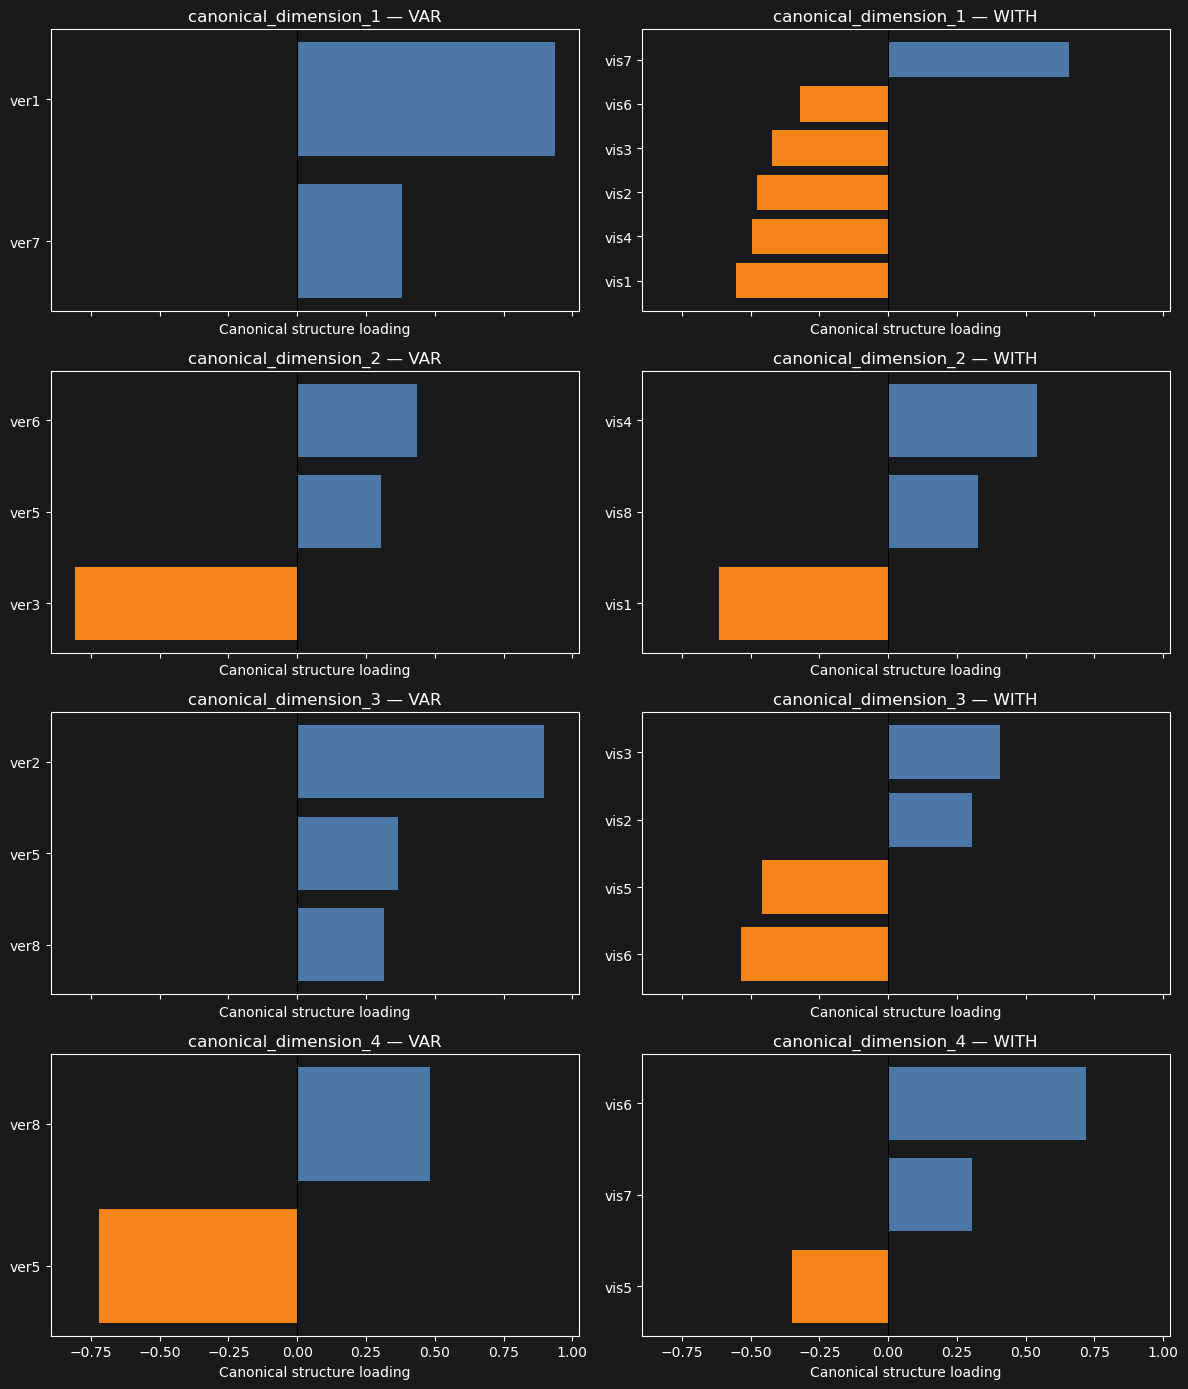

In [8]:
import matplotlib.pyplot as plt

dimensions = sorted(cca_dimension_loadings_df["canonical_dimension"].unique())

fig, axes = plt.subplots(
    nrows=len(dimensions),
    ncols=2,
    figsize=(12, 3.5 * len(dimensions)),
    sharex=True,
)

for row_idx, dimension in enumerate(dimensions):
    for col_idx, modality in enumerate(["VAR", "WITH"]):
        ax = axes[row_idx, col_idx]

        subset = cca_dimension_loadings_df[
            (cca_dimension_loadings_df["canonical_dimension"] == dimension)
            & (cca_dimension_loadings_df["modality"] == modality)
            ].copy()

        subset = subset.sort_values("loading")

        colors = ["#4C78A8" if value >= 0 else "#F58518" for value in subset["loading"]]

        ax.barh(subset["variable"], subset["loading"], color=colors)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"{dimension} — {modality}")
        ax.set_xlabel("Canonical structure loading")
        ax.set_ylabel("")

plt.tight_layout()
plt.show()

These results are **much more interpretable** because they are based on **canonical structure loadings**. They show which original verbal dimensions (`ver<n>`) and visual dimensions (`vis<n>`) correlate most strongly with each canonical variate.

A good way to read each canonical dimension is:

> A CCA dimension links a pattern of verbal dimensions with a pattern of visual dimensions. Variables with the same sign are aligned on the same pole of the dimension; variables with opposite signs define the opposing pole.

Because signs in CCA are arbitrary, you can flip all signs within a dimension without changing the meaning. What matters is the **relative opposition** among variables.

---

## Overall interpretation

You have four interpretable cross-modal dimensions:

| Dimension | Canonical correlation | Main interpretation status |
|---:|---:|---|
| 1 | strongest | Most robust and clearest |
| 2 | strong | Clear verbal–visual opposition |
| 3 | moderate | Interpretable cross-modal contrast |
| 4 | weakest / marginal | Interpret cautiously |

The first three are the most reliable interpretively. The fourth can be discussed, but it should be treated as **tentative** because it is weaker and only marginally significant.

---

# Canonical Dimension 1

```python
VAR:
  ver1 =  0.9356
  ver7 =  0.3808

WITH:
  vis7 =  0.6579
  vis6 = -0.3213
  vis3 = -0.4235
  vis2 = -0.4759
  vis4 = -0.4949
  vis1 = -0.5514
```

## Structure

The verbal side is strongly dominated by:

- `ver1`, very strong positive loading;
- `ver7`, moderate positive loading.

The visual side has:

- positive `vis7`;
- negative `vis1`, `vis4`, `vis2`, `vis3`, and `vis6`.

So dimension 1 contrasts:

```text
ver1/ver7 + vis7
```

against:

```text
vis1/vis4/vis2/vis3/vis6
```

## Interpretation

This is the clearest dimension. It suggests that commercials high on verbal dimension `ver1` and, to a lesser extent, `ver7`, tend to align with visual dimension `vis7`, while contrasting with a cluster of other visual dimensions.

In prose:

> The first canonical dimension links a strongly defined verbal pattern, centred on `ver1` and supported by `ver7`, with a visual contrast in which `vis7` stands opposed to several other visual dimensions, especially `vis1`, `vis4`, `vis2`, and `vis3`.

Because `ver1` is so dominant, this dimension may largely represent the cross-modal relationship between the discourse pattern captured by `ver1` and a visual opposition centred on `vis7`.

---

# Canonical Dimension 2

```python
VAR:
  ver6 =  0.4338
  ver5 =  0.3028
  ver3 = -0.8074

WITH:
  vis4 =  0.5395
  vis8 =  0.3257
  vis1 = -0.6135
```

## Structure

The verbal side contrasts:

- positive `ver6` and `ver5`;
- negative `ver3`.

The visual side contrasts:

- positive `vis4` and `vis8`;
- negative `vis1`.

So dimension 2 links:

```text
ver6/ver5 + vis4/vis8
```

against:

```text
ver3 + vis1
```

More precisely, since `ver3` and `vis1` are both negative, they occupy the same pole. `ver6`, `ver5`, `vis4`, and `vis8` occupy the opposite pole.

## Interpretation

This dimension shows a strong verbal–visual opposition. It suggests that commercials high on `ver6` and `ver5` tend to be visually associated with `vis4` and `vis8`, while commercials high on `ver3` tend to be visually associated with `vis1`.

In prose:

> The second canonical dimension opposes a cross-modal pattern combining `ver6` and `ver5` with visual dimensions `vis4` and `vis8`, against a contrasting pattern combining `ver3` with `vis1`.

This is quite interpretable because both modalities show clear positive and negative poles.

---

# Canonical Dimension 3

```python
VAR:
  ver2 =  0.8978
  ver5 =  0.3671
  ver8 =  0.3150

WITH:
  vis3 =  0.4070
  vis2 =  0.3054
  vis5 = -0.4578
  vis6 = -0.5352
```

## Structure

The verbal side is dominated by:

- `ver2`, very strong positive loading;
- `ver5` and `ver8`, moderate positive loadings.

The visual side contrasts:

- positive `vis3` and `vis2`;
- negative `vis6` and `vis5`.

So dimension 3 links:

```text
ver2/ver5/ver8 + vis3/vis2
```

against:

```text
vis6/vis5
```

There are no major negative verbal dimensions above your threshold, so the verbal side is mainly a positive pole.

## Interpretation

This dimension suggests that commercials high on `ver2`, with support from `ver5` and `ver8`, are associated visually with `vis3` and `vis2`, and opposed to visual dimensions `vis6` and `vis5`.

In prose:

> The third canonical dimension is centred on a strong verbal pattern defined by `ver2`, with additional contributions from `ver5` and `ver8`. This verbal pattern aligns with visual dimensions `vis3` and `vis2`, and contrasts with visual dimensions `vis6` and `vis5`.

This dimension is less balanced than dimension 2 because the verbal side does not show a clear negative pole above the cutoff, but the visual side has a clear positive–negative contrast.

---

# Canonical Dimension 4

```python
VAR:
  ver8 =  0.4820
  ver5 = -0.7196

WITH:
  vis6 =  0.7197
  vis7 =  0.3060
  vis5 = -0.3477
```

## Structure

The verbal side contrasts:

- positive `ver8`;
- negative `ver5`.

The visual side contrasts:

- positive `vis6` and `vis7`;
- negative `vis5`.

So dimension 4 links:

```text
ver8 + vis6/vis7
```

against:

```text
ver5 + vis5
```

## Interpretation

This dimension suggests a cross-modal opposition between:

- a pole characterised by verbal `ver8` and visual `vis6`/`vis7`;
- an opposite pole characterised by verbal `ver5` and visual `vis5`.

In prose:

> The fourth canonical dimension opposes a pattern in which `ver8` aligns with `vis6` and `vis7`, against a contrasting pattern in which `ver5` aligns with `vis5`.

This is actually structurally quite interpretable, but statistically it is weaker. So I would write:

> Although this dimension has a coherent loading pattern, it should be interpreted cautiously because its canonical correlation is small and its significance is marginal.

---

## Suggested summary table

| Dimension | Positive verbal pole | Negative verbal pole | Positive visual pole | Negative visual pole |
|---:|---|---|---|---|
| 1 | `ver1`, `ver7` | — | `vis7` | `vis1`, `vis4`, `vis2`, `vis3`, `vis6` |
| 2 | `ver6`, `ver5` | `ver3` | `vis4`, `vis8` | `vis1` |
| 3 | `ver2`, `ver5`, `ver8` | — | `vis3`, `vis2` | `vis6`, `vis5` |
| 4 | `ver8` | `ver5` | `vis6`, `vis7` | `vis5` |

---

## Suggested write-up

You could write something like:

> The canonical structure loadings reveal four cross-modal dimensions linking verbal and visual factor scores. The first dimension is dominated by `ver1` on the verbal side and contrasts `vis7` with a broader cluster of negative visual loadings (`vis1`, `vis4`, `vis2`, `vis3`, and `vis6`). The second dimension opposes a pattern combining `ver6`, `ver5`, `vis4`, and `vis8` against a contrasting pole defined by `ver3` and `vis1`. The third dimension is centred on `ver2`, supported by `ver5` and `ver8`, and visually aligns with `vis3` and `vis2` while contrasting with `vis6` and `vis5`. The fourth dimension contrasts `ver8` and `vis6`/`vis7` with `ver5` and `vis5`; however, this dimension should be treated cautiously because it is weaker and only marginally significant.

---

## Important next step

To make the interpretation substantive, you now need to replace labels like:

```text
ver1, ver2, vis1, vis2
```

with the actual discourse/factor interpretations from Phase 2 and Phase 3.

For example, if `ver1` represents something like “product-benefit claims” and `vis7` represents “domestic/family imagery”, then dimension 1 becomes interpretable as a cross-modal discourse pattern linking those two factor meanings.

So the statistical interpretation is ready, but the **linguistic/discourse interpretation depends on your factor labels**.